# LayerNorm Kernel Benchmark — RTX 5080, sm_120

Comparing all five CUDA kernel versions against PyTorch (eager + compiled) and Triton.

| Kernel | Strategy | HBM passes |
|--------|----------|------------|
| V1 | One thread per row — serial | 3R + 1W |
| V2 | One block per row — warp + block reduction | 3R + 1W |
| V3 | Parallel Welford — single‑pass mean+var | 2R + 1W |
| V4 | V2 with shared‑memory row cache | 1R + 1W |
| V5 | V2 with float4 vectorised loads/stores | 3R + 1W |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Data (µs) ─────────────────────────────────────────────────────────────────
# CUDA timings: ./build/bin/layerNorm_sm120 N C  →  Median Time (ms) * 1000
# Python timings: benchmark/sweep_layernorm.py  →  median µs

sizes = [
    '512×1024', '1024×1024', '2048×1024', '4096×1024',
    '8192×1024', '8192×2048', '8192×4096'
]

v1       = [428.0, 426.0, 423.9, 423.9, 461.6, 837.6, 1929.7]
v2       = [ 12.0,  14.0,  22.2,  40.5,  79.5, 170.0,  339.6]
v3       = [ 12.3,  16.4,  22.5,  45.1,  86.0, 172.0,  335.9]
v4       = [ 12.3,  16.4,  22.5,  45.1,  86.0, 170.0,  333.8]
v5       = [  8.2,  12.0,  22.5,  43.0,  85.7, 169.7,  331.4]
pytorch  = [  8.2,  14.0,  26.3,  47.1,  88.1, 167.6,  423.9]
compiled = [  5.8,  10.2,  22.2,  42.7,  83.6, 165.6,  329.7]
triton   = [  8.2,  12.3,  24.6,  43.5,  84.3, 164.2,  328.0]

# ── Dark theme ────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
GRID_C = '#ffffff'
TEXT   = '#e6edf3'
BLUE   = '#58a6ff'
ORANGE = '#f78166'
GREEN  = '#3fb950'
PURPLE = '#bc8cff'
YELLOW = '#e3b341'
PINK   = '#ff7b72'
TEAL   = '#39d353'

plt.rcParams.update({
    'font.family':        'monospace',
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        TEXT,
    'ytick.color':        TEXT,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#30363d',
    'axes.grid':          True,
    'grid.color':         GRID_C,
    'grid.alpha':         0.06,
    'grid.linestyle':     '-',
    'grid.linewidth':     0.5,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
})

x = np.arange(len(sizes))
print('Data loaded.')

Data loaded.


## 1 — All kernels: latency across sizes

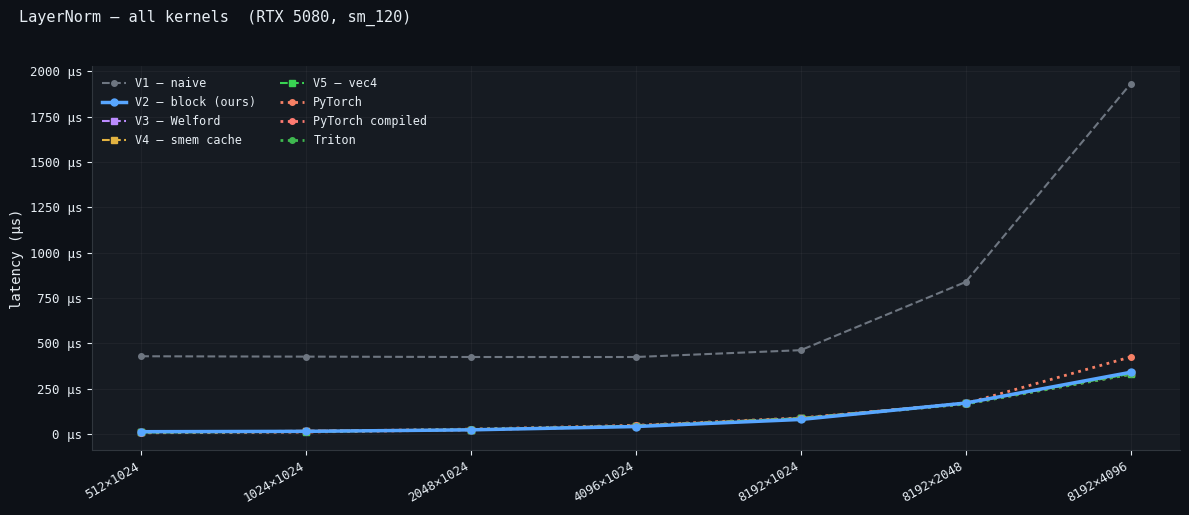

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

# CUDA kernels
ax.plot(x, v1,       color='#6e7681', linewidth=1.5, marker='o', markersize=4,
        linestyle='--', label='V1 — naive', zorder=2)
ax.plot(x, v2,       color=BLUE,      linewidth=2.5, marker='o', markersize=5,
        label='V2 — block (ours)', zorder=4)
ax.plot(x, v3,       color=PURPLE,    linewidth=1.5, marker='s', markersize=4,
        linestyle='--', label='V3 — Welford', zorder=2)
ax.plot(x, v4,       color=YELLOW,    linewidth=1.5, marker='s', markersize=4,
        linestyle='--', label='V4 — smem cache', zorder=2)
ax.plot(x, v5,       color=TEAL,      linewidth=1.5, marker='s', markersize=4,
        linestyle='--', label='V5 — vec4', zorder=2)
# Baselines
ax.plot(x, pytorch,  color=ORANGE,    linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='PyTorch', zorder=3)
ax.plot(x, compiled, color=PINK,      linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='PyTorch compiled', zorder=3)
ax.plot(x, triton,   color=GREEN,     linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='Triton', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=8.5, framealpha=0, loc='upper left', labelcolor=TEXT, ncol=2)
ax.tick_params(labelsize=9)

fig.suptitle('LayerNorm — all kernels  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('layernorm_all.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 2 — V2 vs best baselines: latency across sizes

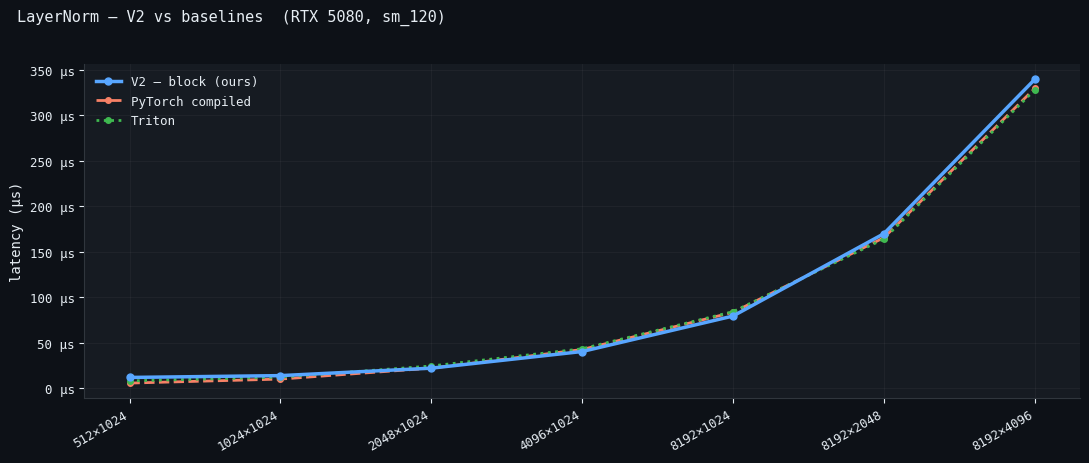

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(x, v2,       color=BLUE,   linewidth=2.5, marker='o', markersize=5,
        label='V2 — block (ours)', zorder=4)
ax.plot(x, compiled, color=ORANGE, linewidth=2,   marker='o', markersize=4,
        linestyle='--', label='PyTorch compiled', zorder=3)
ax.plot(x, triton,   color=GREEN,  linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='Triton', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, loc='upper left', labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('LayerNorm — V2 vs baselines  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('layernorm_v2_vs_baselines.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 3 — Sizes where V2 beats both PyTorch compiled and Triton

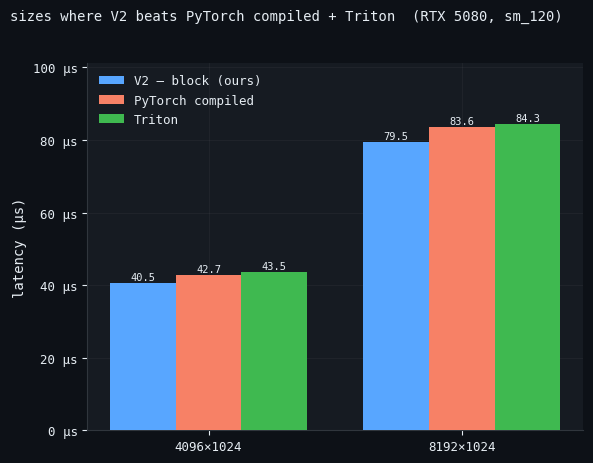

V2 wins at 2/7 sizes tested.


In [4]:
win_idx   = [i for i in range(len(sizes)) if v2[i] < compiled[i] and v2[i] < triton[i]]
win_sizes = [sizes[i]    for i in win_idx]
bb_vals   = [v2[i]       for i in win_idx]
cmp_vals  = [compiled[i] for i in win_idx]
tri_vals  = [triton[i]   for i in win_idx]

n      = len(win_sizes)
xw     = np.arange(n)
width  = 0.26

fig, ax = plt.subplots(figsize=(max(6, n * 2.2), 4.5))

b1 = ax.bar(xw - width, bb_vals,  width, label='V2 — block (ours)',    color=BLUE,   zorder=3)
b2 = ax.bar(xw,         cmp_vals, width, label='PyTorch compiled', color=ORANGE, zorder=3)
b3 = ax.bar(xw + width, tri_vals, width, label='Triton',           color=GREEN,  zorder=3)

for bars in (b1, b2, b3):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=7.5, color=TEXT
        )

ax.set_xticks(xw)
ax.set_xticklabels(win_sizes, fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)
ax.set_ylim(0, max(cmp_vals + tri_vals) * 1.2)

fig.suptitle('sizes where V2 beats PyTorch compiled + Triton  (RTX 5080, sm_120)',
             fontsize=10, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('layernorm_wins.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'V2 wins at {len(win_idx)}/{len(sizes)} sizes tested.')

## 4 — Kernel progression at 8192×1024

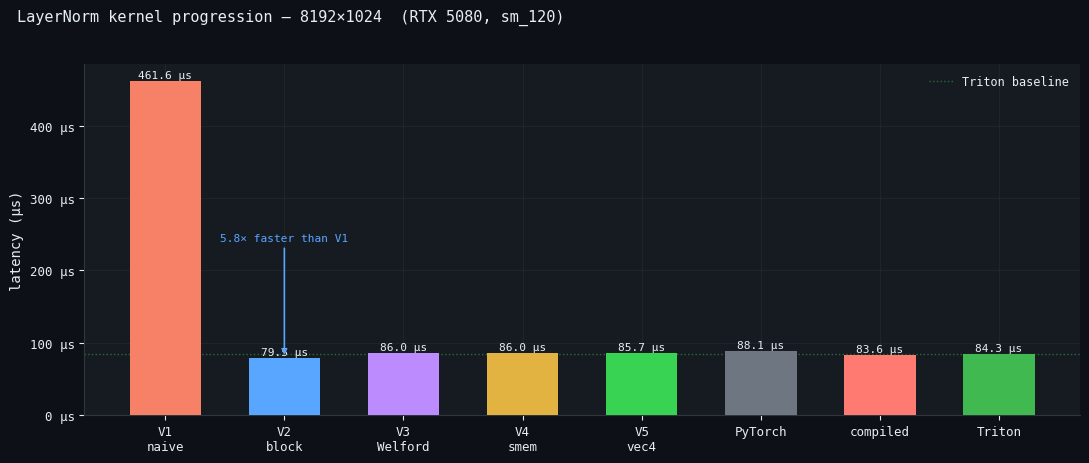

In [5]:
# Fixed size: 8192×1024 (index 4)
IDX = 4

kern_names = ['V1\nnaive', 'V2\nblock', 'V3\nWelford', 'V4\nsmem', 'V5\nvec4',
              'PyTorch', 'compiled', 'Triton']
kern_vals  = [v1[IDX], v2[IDX], v3[IDX], v4[IDX], v5[IDX],
              pytorch[IDX], compiled[IDX], triton[IDX]]
kern_colors = [ORANGE, BLUE, PURPLE, YELLOW, TEAL, '#6e7681', PINK, GREEN]

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(range(len(kern_names)), kern_vals, color=kern_colors, zorder=3, width=0.6)

for bar, val in zip(bars, kern_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{val:.1f} µs',
        ha='center', va='bottom', fontsize=8, color=TEXT
    )

ax.axhline(triton[IDX], color=GREEN, linewidth=1, linestyle=':', alpha=0.5, label='Triton baseline')

ax.set_xticks(range(len(kern_names)))
ax.set_xticklabels(kern_names, fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=8.5, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)

# Annotate speedup of V2 over V1
speedup = v1[IDX] / v2[IDX]
ax.annotate(
    f'{speedup:.1f}× faster than V1',
    xy=(1, v2[IDX]), xytext=(1, v2[IDX] + v1[IDX] * 0.35),
    fontsize=8, color=BLUE, ha='center',
    arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2)
)

fig.suptitle(f'LayerNorm kernel progression — {sizes[IDX]}  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('layernorm_progression.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 5 — Speedup of V2 over PyTorch compiled, across sizes

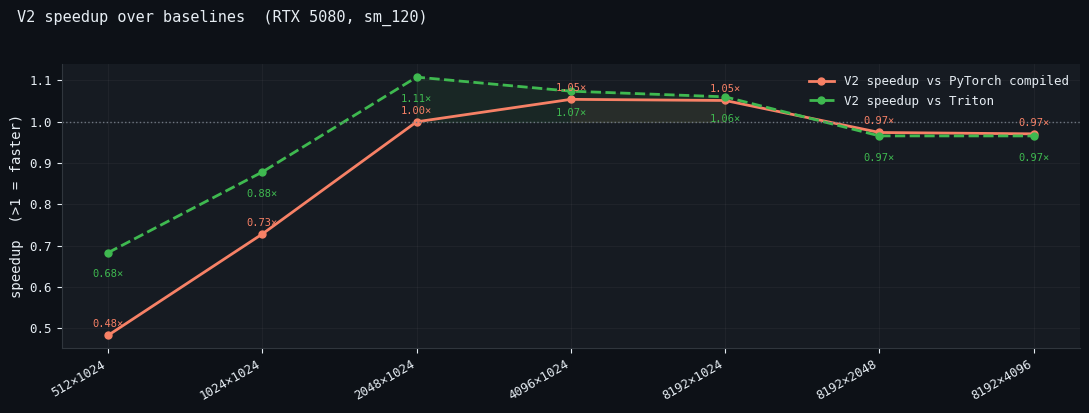

In [6]:
speedups_compiled = [c / b for c, b in zip(compiled, v2)]
speedups_triton   = [t / b for t, b in zip(triton,   v2)]

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(x, speedups_compiled, color=ORANGE, linewidth=2, marker='o', markersize=5,
        label='V2 speedup vs PyTorch compiled')
ax.plot(x, speedups_triton,   color=GREEN,  linewidth=2, marker='o', markersize=5,
        linestyle='--', label='V2 speedup vs Triton')
ax.axhline(1.0, color='#6e7681', linewidth=1, linestyle=':')
ax.fill_between(x, 1.0, speedups_compiled,
                where=[s > 1 for s in speedups_compiled],
                color=ORANGE, alpha=0.08)
ax.fill_between(x, 1.0, speedups_triton,
                where=[s > 1 for s in speedups_triton],
                color=GREEN, alpha=0.08)

for i, (sc, st) in enumerate(zip(speedups_compiled, speedups_triton)):
    ax.text(i, sc + 0.02, f'{sc:.2f}×', ha='center', fontsize=7.5, color=ORANGE)
    ax.text(i, st - 0.06, f'{st:.2f}×', ha='center', fontsize=7.5, color=GREEN)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('speedup  (>1 = faster)', fontsize=10)
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('V2 speedup over baselines  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('layernorm_speedup.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()